<a href="https://colab.research.google.com/github/fauziahroikhanawar/Klasifikasi_Aksara_Jawa_CNN/blob/main/notebook/klasifikasi_aksara_jawa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install opencv-python matplotlib numpy scikit-learn tensorflow scikit-image kagglehub

#Import Library

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models
from skimage.morphology import skeletonize
import tensorflow as tf
import kagglehub

import warnings
warnings.filterwarnings('ignore')

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

import kagglehub
downloaded_path = kagglehub.dataset_download("vzrenggamani/hanacaraka")
DATASET_PATH = downloaded_path
CLASSES      = ['da', 'ta', 'sa', 'wa', 'la']
TARGET_SIZE  = (64, 64)

100%|██████████| 9.20M/9.20M [00:00<00:00, 105MB/s]

Extracting files...


In [ ]:
print(os.listdir(DATASET_PATH))

['ca', 'ka', 'ya', 'README.md', 'nya', 'ga', 'da', 'la', 'pa', 'ba', 'nga', 'na', 'LICENSE.md', 'dha', 'wa', 'ma', 'tha', 'LICENSE', 'sa', 'ha', 'ja', 'ra', 'ta']


#Load Dataset

In [ ]:
def load_dataset(dataset_path, classes):
    images, labels = [], []
    for label in classes:
        class_dir = Path(dataset_path) / label
        if not class_dir.exists():
            print(f"Folder tidak ditemukan: {class_dir}")
            continue
        img_files = list(class_dir.glob('*.png')) + \
                    list(class_dir.glob('*.jpg')) + \
                    list(class_dir.glob('*.jpeg'))
        loaded = 0
        for img_path in img_files:
            img = cv2.imread(str(img_path))
            if img is not None:
                images.append(img)
                labels.append(label)
                loaded += 1
        print(f"Kelas '{label}': {loaded} gambar dimuat")  # ← hitungan yang berhasil
    print(f"Total: {len(images)} gambar")
    return images, labels

images, labels = load_dataset(DATASET_PATH, CLASSES)

Kelas 'da': 79 gambar dimuat
Kelas 'ta': 76 gambar dimuat
Kelas 'sa': 79 gambar dimuat
Kelas 'wa': 79 gambar dimuat
Kelas 'la': 78 gambar dimuat
Total: 391 gambar


#EDA

Distribusi Kelas
  da: 79 gambar
  ta: 76 gambar
  sa: 79 gambar
  wa: 79 gambar
  la: 78 gambar

Cek Balance Data
Rasio (maks/min): 1.04x
Balance


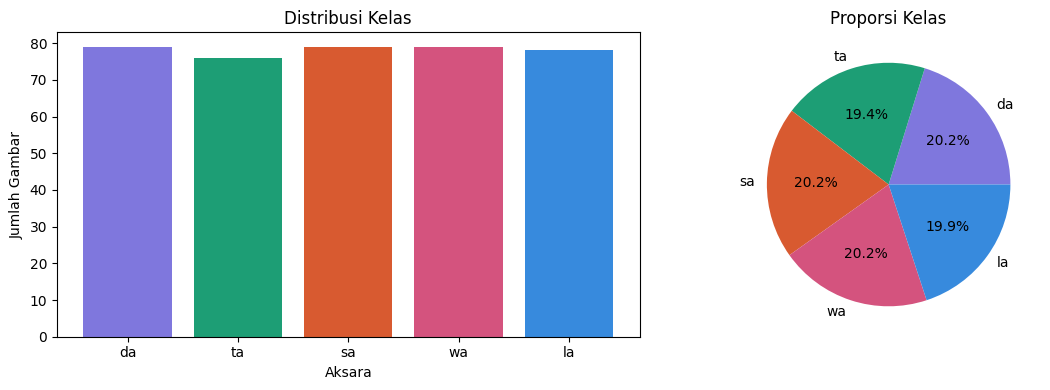

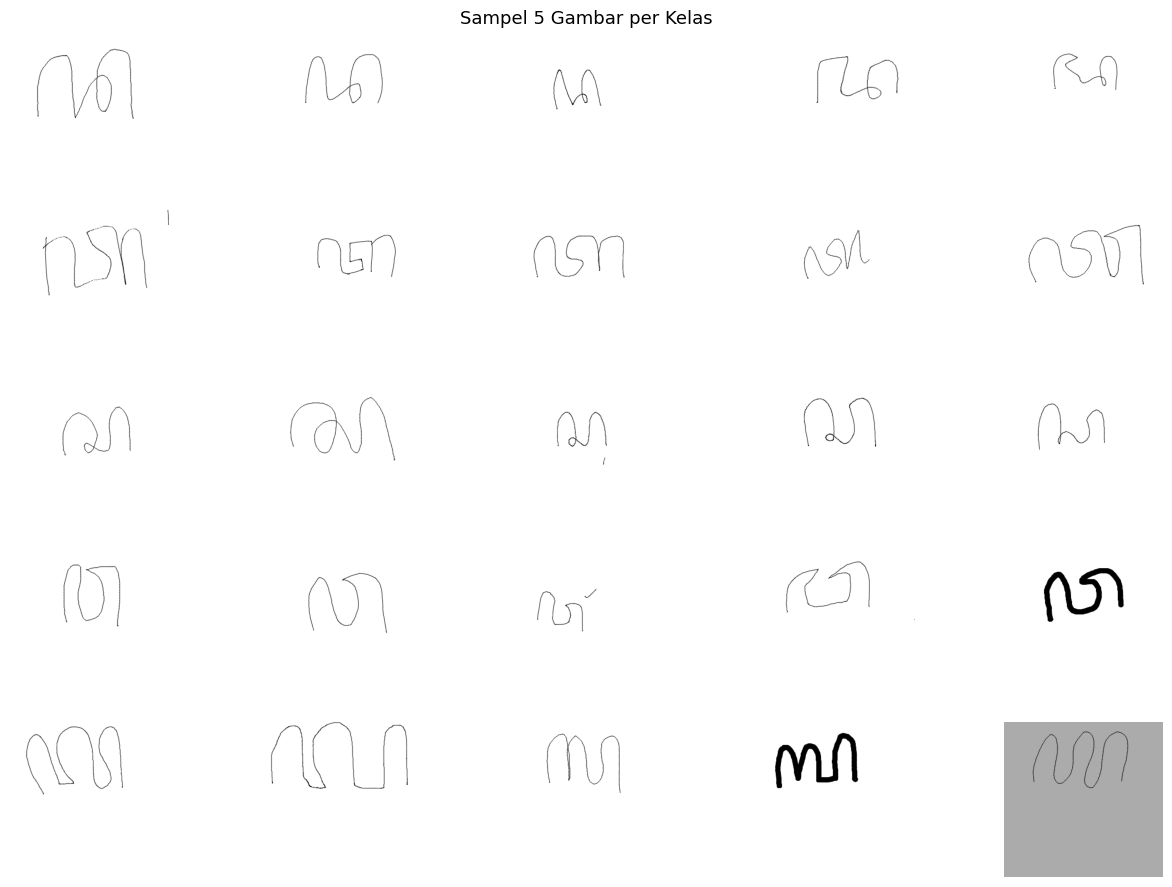

In [ ]:
def explore_dataset(images, labels):
    dist   = Counter(labels)
    counts = list(dist.values())

    # Distribusi
    print("Distribusi Kelas")
    for cls, count in dist.items():
        print(f"  {cls}: {count} gambar")

    # Cek balance data
    ratio = max(counts) / min(counts)
    print(f"\nCek Balance Data")
    print(f"Rasio (maks/min): {ratio:.2f}x")
    if ratio <= 1.5:
        print("Balance")
    else:
        print("Imbalance")

    # Plot distribusi
    colors = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E', '#378ADD']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(list(dist.keys()), counts, color=colors)
    axes[0].set_title('Distribusi Kelas')
    axes[0].set_xlabel('Aksara')
    axes[0].set_ylabel('Jumlah Gambar')
    axes[1].pie(counts, labels=list(dist.keys()), colors=colors, autopct='%1.1f%%')
    axes[1].set_title('Proporsi Kelas')
    plt.tight_layout()
    plt.show()

    # Sampel gambar per kelas
    fig2, axes2 = plt.subplots(len(CLASSES), 5, figsize=(13, 9))
    for row, cls in enumerate(CLASSES):
        cls_imgs = [img for img, lbl in zip(images, labels) if lbl == cls]
        for col in range(5):
            ax = axes2[row][col]
            if col < len(cls_imgs):
                ax.imshow(cv2.cvtColor(cls_imgs[col], cv2.COLOR_BGR2RGB))
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(cls, fontsize=12, rotation=0, labelpad=30)
    fig2.suptitle('Sampel 5 Gambar per Kelas', fontsize=13)
    plt.tight_layout()
    plt.show()

explore_dataset(images, labels)

#Pre-Processing

###GrayScale

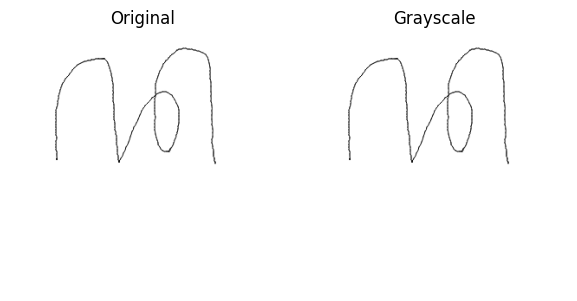

In [ ]:
def to_grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img.copy()

gray = to_grayscale(images[0])
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
ax[0].set_title('Original')
ax[0].axis('off')
ax[1].imshow(gray, cmap='gray')
ax[1].set_title('Grayscale')
ax[1].axis('off')
plt.tight_layout()
plt.show()

### Noise Removal
Filter median dipilih karena efektif menghilangkan noise pada gambar tulisan tangan.

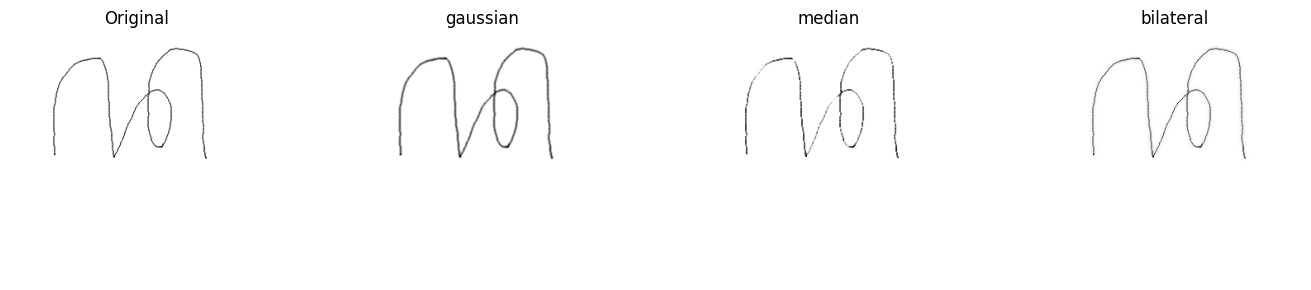

In [ ]:
def remove_noise(gray, method='median'):
    if method == 'gaussian':
        return cv2.GaussianBlur(gray, (3, 3), 0)
    elif method == 'median':
        return cv2.medianBlur(gray, 3)
    elif method == 'bilateral':
        return cv2.bilateralFilter(gray, 9, 75, 75)

# Bandingkan ketiga metode
gray = to_grayscale(images[0])
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original')
for i, m in enumerate(['gaussian', 'median', 'bilateral']):
    axes[i+1].imshow(remove_noise(gray, m), cmap='gray')
    axes[i+1].set_title(m)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

### Thresholding (Binarisasi)
Mengubah gambar grayscale menjadi hitam-putih untuk memisahkan stroke dari background.

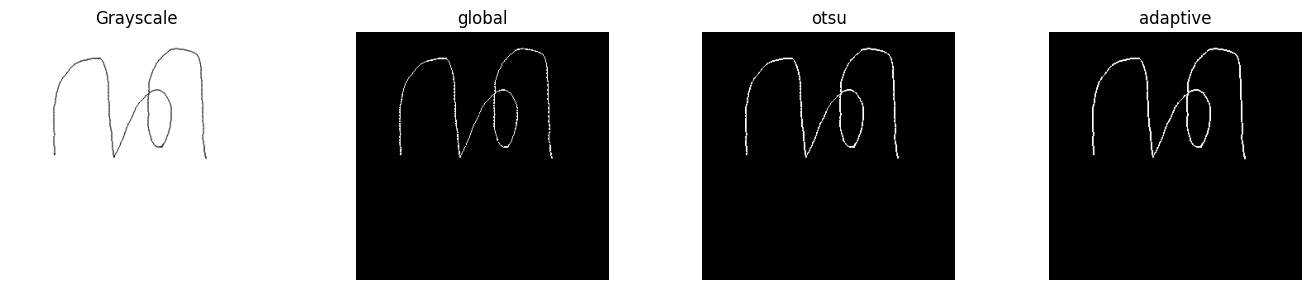

In [ ]:
def apply_threshold(gray, method='otsu'):
    if method == 'global':
        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    elif method == 'otsu':
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    elif method == 'adaptive':
        binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY_INV, 11, 2)
    return binary

# Bandingkan ketiga metode
gray = to_grayscale(images[0])
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale')
for i, m in enumerate(['global', 'otsu', 'adaptive']):
    axes[i+1].imshow(apply_threshold(gray, m), cmap='gray')
    axes[i+1].set_title(m)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

###Morfologi
Closing digunakan untuk menutup celah/putus-putus pada stroke aksara.

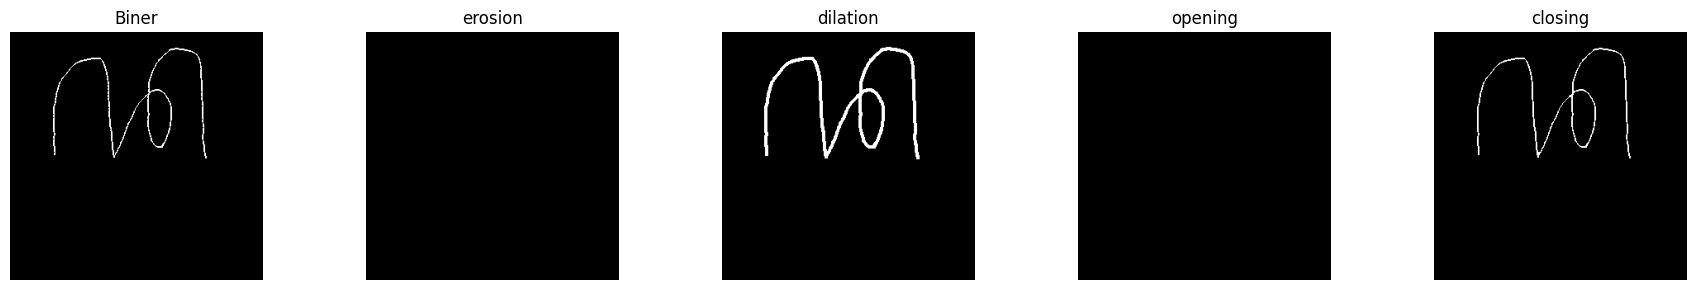

In [ ]:
def apply_morphology(binary, operation='closing'):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    ops = {'erosion': cv2.MORPH_ERODE, 'dilation': cv2.MORPH_DILATE,
           'opening': cv2.MORPH_OPEN,  'closing':  cv2.MORPH_CLOSE}
    return cv2.morphologyEx(binary, ops[operation], kernel)

# Bandingkan keempat operasi
gray   = to_grayscale(images[0])
binary = apply_threshold(gray, 'otsu')
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Biner')
for i, op in enumerate(['erosion', 'dilation', 'opening', 'closing']):
    axes[i+1].imshow(apply_morphology(binary, op), cmap='gray')
    axes[i+1].set_title(op)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

### Skeletonization
Mereduksi stroke menjadi 1 piksel agar tebal-tipis tulisan tidak mempengaruhi model.

>Manfaat: menghilangkan variasi ketebalan tulisan antar penulis. Semua orang yang menulis 'da' akan menghasilkan skeleton yang mirip, meskipun ada yang menulis tebal dan ada yang tipis.

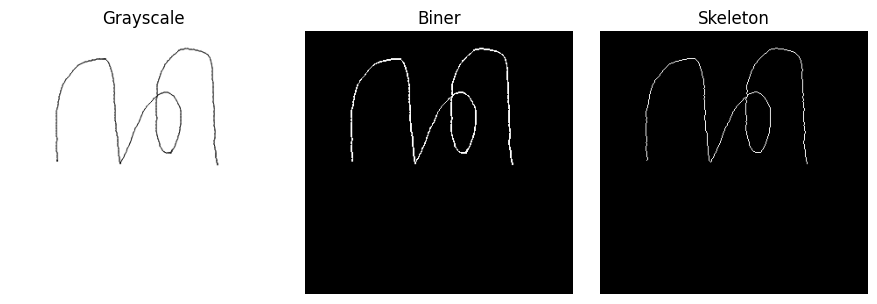

In [ ]:
def apply_skeleton(binary):
    skel = skeletonize(binary / 255.0)
    return (skel * 255).astype(np.uint8)

# Contoh
gray   = to_grayscale(images[0])
binary = apply_threshold(gray, 'otsu')
skel   = apply_skeleton(binary)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(gray,   cmap='gray')
axes[0].set_title('Grayscale')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Biner')
axes[2].imshow(skel,   cmap='gray')
axes[2].set_title('Skeleton')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

### Resize & Normalisasi
Semua gambar diseragamkan ke ukuran 64×64 piksel, lalu nilai piksel dinormalisasi ke [0, 1].

In [ ]:
def resize_normalize(img):
    resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0

### Pipeline & Konfigurasi Eksperimen
Semua tahap digabung dalam satu fungsi `preprocess()` yang bisa dikonfigurasi.

In [ ]:
def preprocess(img, config):
    result = to_grayscale(img)
    if config.get('noise'):      result = remove_noise(result, config['noise'])
    if config.get('threshold'):  result = apply_threshold(result, config['threshold'])
    if config.get('morphology'): result = apply_morphology(result, config['morphology'])
    if config.get('skeleton'):   result = apply_skeleton(result)
    result = resize_normalize(result)
    return np.expand_dims(result, axis=-1)  # → (64, 64, 1)

EXPERIMENTS = {
    'baseline':         {'noise': None,     'threshold': None,       'morphology': None,      'skeleton': False},
    'exp1_otsu':        {'noise': None,     'threshold': 'otsu',     'morphology': None,      'skeleton': False},
    'exp2_median_otsu': {'noise': 'median', 'threshold': 'otsu',     'morphology': None,      'skeleton': False},
    'exp3_full':        {'noise': 'median', 'threshold': 'otsu',     'morphology': 'closing', 'skeleton': False},
    'exp4_skeleton':    {'noise': 'median', 'threshold': 'otsu',     'morphology': 'closing', 'skeleton': True},
}

def process_all(images, labels, config):
    X = [preprocess(img, config) for img in images]
    y = [CLASSES.index(lbl) for lbl in labels]
    return np.array(X, dtype=np.float32), np.array(y)

print("Preprocessing siap. Total eksperimen:", len(EXPERIMENTS))

Preprocessing siap. Total eksperimen: 5


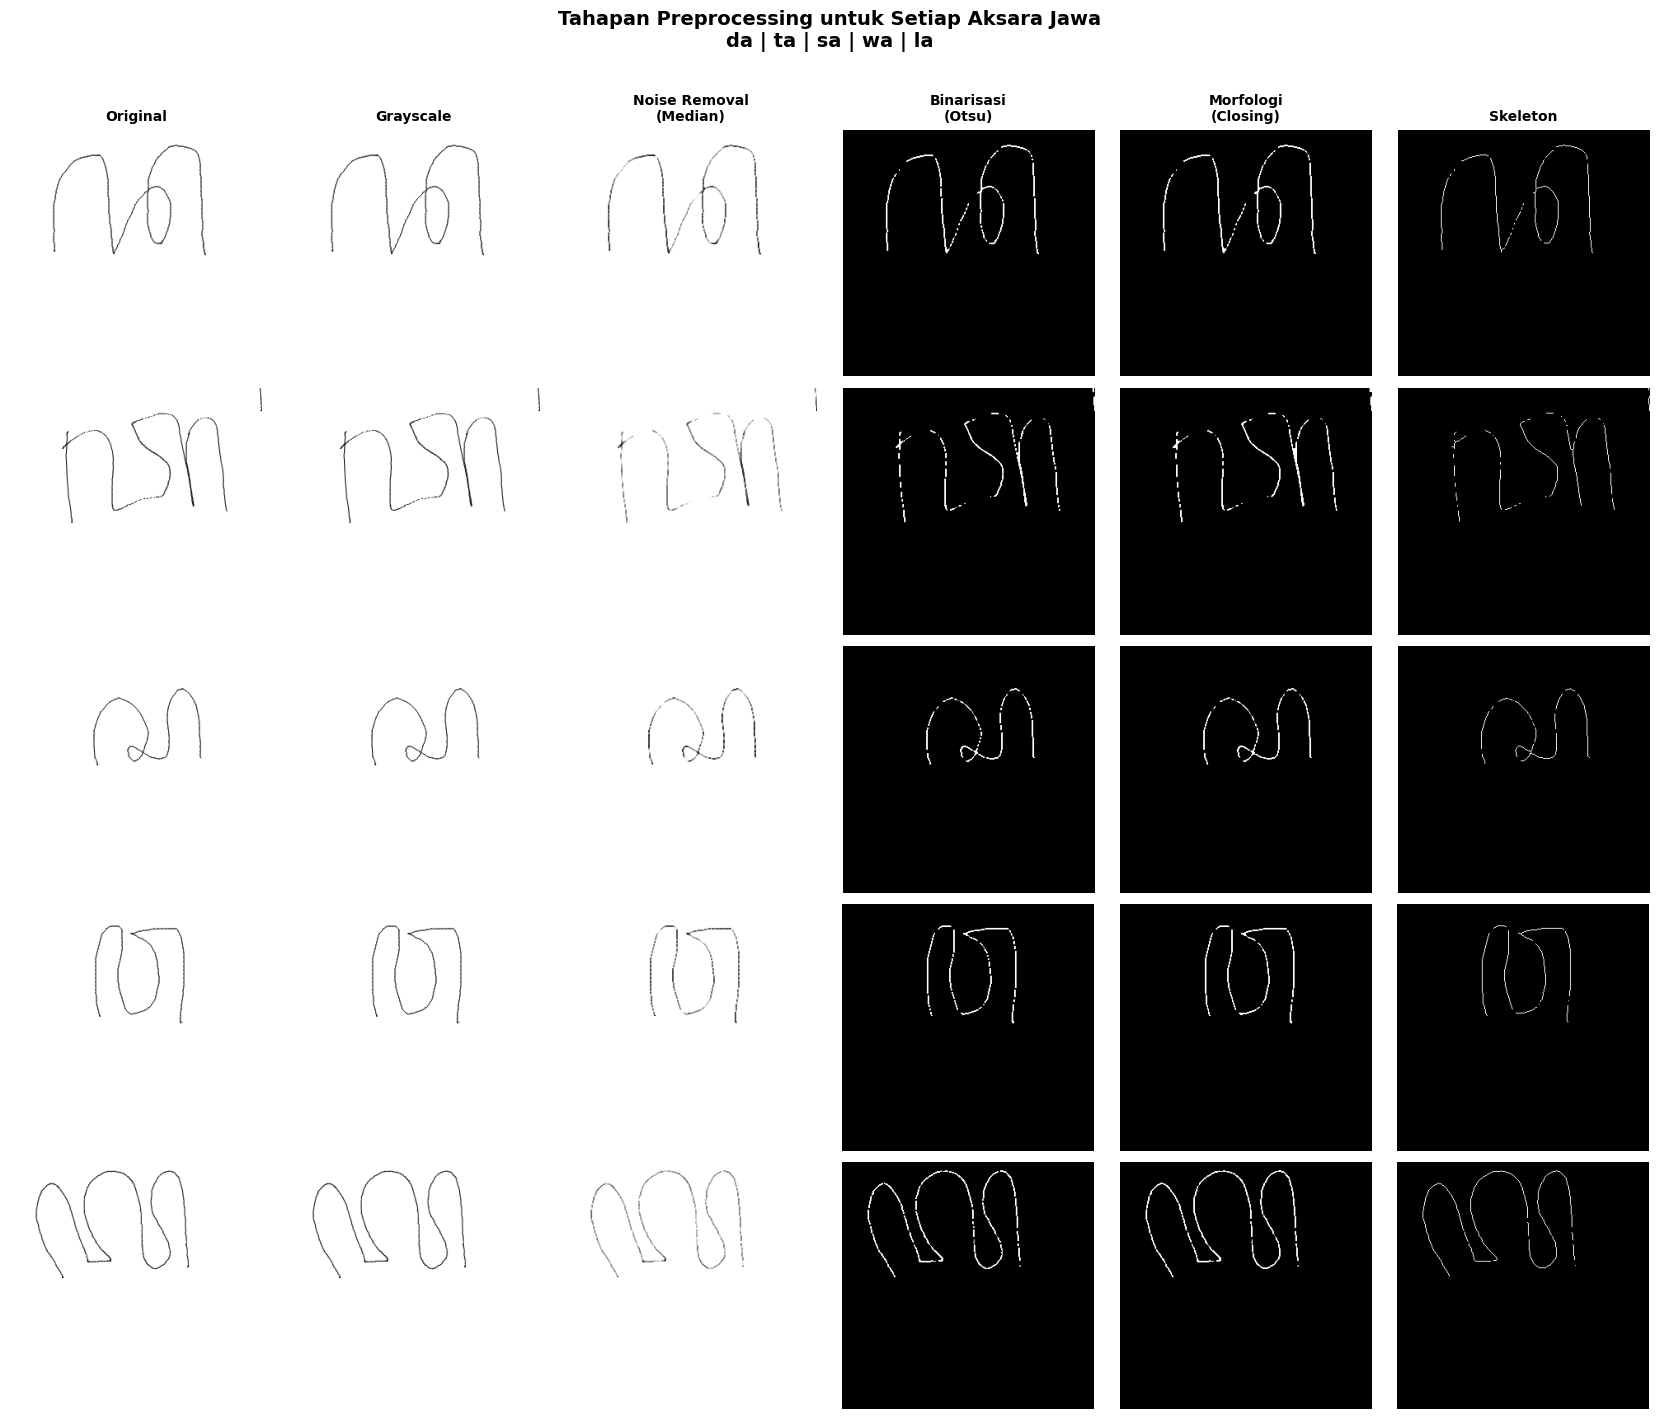

In [ ]:
# Visualisasi Tahap Preprocessing
# tahap: Original → Grayscale → Biner → Morfologi → Skeleton
def visualize_preprocessing_steps(images, labels):
    step_names = [
        'Original',
        'Grayscale',
        'Noise Removal\n(Median)',
        'Binarisasi\n(Otsu)',
        'Morfologi\n(Closing)',
        'Skeleton'
    ]
    n_steps = len(step_names)
    n_classes = len(CLASSES)

    # Ambil 1 sampel representatif per kelas
    samples = {}
    for cls in CLASSES:
        for img, lbl in zip(images, labels):
            if lbl == cls:
                samples[cls] = img
                break

    fig, axes = plt.subplots(
        n_classes, n_steps,
        figsize=(n_steps * 2.8, n_classes * 2.8)
    )

    for row, cls in enumerate(CLASSES):
        img = samples[cls]

        # Hitung tiap tahap secara manual
        gray     = to_grayscale(img)
        denoised = remove_noise(gray, method='median')
        binary   = apply_threshold(denoised, method='otsu')
        morph    = apply_morphology(binary, operation='closing')
        skel_img = apply_skeleton(morph)

        stages = [
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),  # Original (RGB)
            gray,       # Grayscale
            denoised,   # After noise removal
            binary,     # After binarization
            morph,      # After morphology
            skel_img    # After skeleton (sudah 0-255)
        ]

        for col, (stage, name) in enumerate(zip(stages, step_names)):
            ax = axes[row][col]
            if col == 0:
                ax.imshow(stage)
            else:
                ax.imshow(stage, cmap='gray')
            ax.axis('off')

            if row == 0:
                ax.set_title(name, fontsize=10, fontweight='bold', pad=6)

            if col == 0:
                ax.set_ylabel(
                    cls, fontsize=13, fontweight='bold',
                    rotation=0, labelpad=35, va='center'
                )

    fig.suptitle(
        'Tahapan Preprocessing untuk Setiap Aksara Jawa\n'
        'da | ta | sa | wa | la',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

visualize_preprocessing_steps(images, labels)


## Split Data
Train 80% / Validasi 10% / Test 10%

Membagi data menjadi 3 bagian:
- Train (80%): data yang digunakan untuk melatih model
- Val   (10%): memantau performa selama training (early stopping)
- Test  (10%): evaluasi FINAL, tidak pernah dilihat model saat training

In [ ]:
def split_data(X, y, n_classes=5):
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=1/9, random_state=42, stratify=y_tv
    )

    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
    return (X_train, to_categorical(y_train, n_classes)), \
           (X_val,   to_categorical(y_val,   n_classes)), \
           (X_test,  to_categorical(y_test,  n_classes)), y_test

print("Fungsi split_data siap.")

Fungsi split_data siap.


## Augmentasi Data Training
Membuat variasi buatan dari gambar training agar model lebih robust.
Augmentasi hanya diterapkan pada data train, bukan val/test.

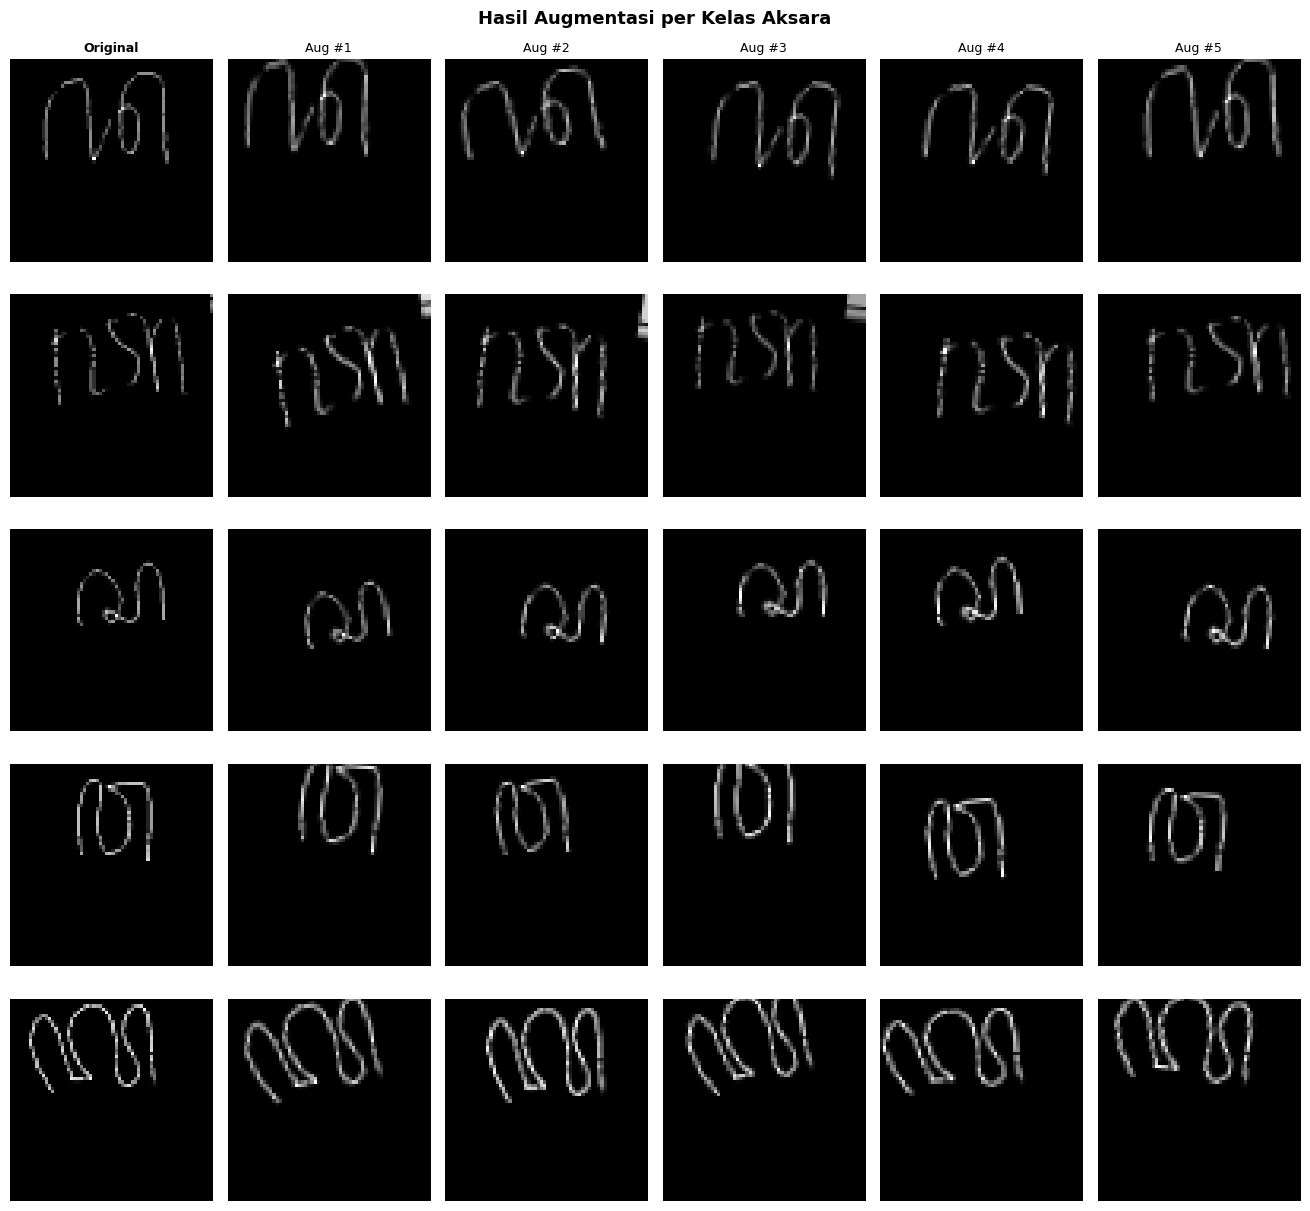

In [ ]:
def get_augmentor():
    return ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        fill_mode='nearest',
        horizontal_flip=False
    )

# Visualisasi hasil augmentasi per kelas
def visualize_augmentation(images, labels, n_aug=5):
    aug = get_augmentor()
    fig, axes = plt.subplots(len(CLASSES), 1 + n_aug, figsize=((1 + n_aug) * 2.2, len(CLASSES) * 2.5))

    for row, cls in enumerate(CLASSES):
        img = next(img for img, lbl in zip(images, labels) if lbl == cls)
        preprocessed = preprocess(img, EXPERIMENTS['exp2_median_otsu'])  # (64,64,1)
        batch = preprocessed[np.newaxis, ...]                             # (1,64,64,1)

        # Kolom 0: gambar asli (sudah preprocessed)
        axes[row][0].imshow(preprocessed[:, :, 0], cmap='gray')
        axes[row][0].axis('off')
        axes[row][0].set_ylabel(cls, fontsize=12, fontweight='bold', rotation=0, labelpad=30, va='center')
        if row == 0:
            axes[row][0].set_title('Original', fontsize=9, fontweight='bold')

        # Kolom 1+: hasil augmentasi
        gen = aug.flow(batch, batch_size=1)
        for col in range(1, 1 + n_aug):
            aug_img = next(gen)[0, :, :, 0]
            axes[row][col].imshow(aug_img, cmap='gray')
            axes[row][col].axis('off')
            if row == 0:
                axes[row][col].set_title(f'Aug #{col}', fontsize=9)

    fig.suptitle('Hasil Augmentasi per Kelas Aksara', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_augmentation(images, labels)

#Arsitektur CNN

    CNN 3 lapis konvolusi.

    Setiap blok Conv → ReLU → MaxPool:
    - Conv2D  : detektor fitur (tepi, lengkungan, sudut stroke)
    - ReLU    : aktivasi non-linear (piksel negatif → 0)
    - MaxPool : mereduksi ukuran, mengambil fitur dominan

    Semakin dalam lapisan, semakin abstrak fitur yang dipelajari
    - Layer 1 (32 filter) : tepi dan garis
    - Layer 2 (64 filter) : kombinasi garis / sudut
    - Layer 3 (128 filter): pola kompleks / bentuk karakter

    CNN dibuat agar perbedaan akurasi
    antar eksperimen murni mencerminkan kualitas preprocessing.

In [ ]:
def build_cnn(input_shape=(64, 64, 1), n_classes=5):
    model = models.Sequential([
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

build_cnn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,191,365 (8.36 MB)

 Trainable params: 2,191,365 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

#Training dengan Early Stopping

    Melatih model dengan dua callback penting

    EarlyStopping, menghentikan training jika val_loss tidak membaik
    selama 'patience' epoch. Mencegah overfitting otomatis.

    ModelCheckpoint, menyimpan model terbaik (val_accuracy tertinggi)
    secara otomatis selama training.

In [ ]:
def train_model(model, train_data, val_data, exp_name, epochs=50):
    X_train, y_train = train_data
    X_val,   y_val   = val_data
    aug = get_augmentor()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint(f'best_{exp_name}.keras', monitor='val_accuracy', save_best_only=True)
    ]

    history = model.fit(
        aug.flow(X_train, y_train, batch_size=32),
        epochs=epochs, validation_data=(X_val, y_val),
        callbacks=callbacks, verbose=1
    )

    # Plot loss & accuracy
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_title('Loss Curve')
    axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='train')
    axes[1].plot(history.history['val_accuracy'], label='val')
    axes[1].set_title('Accuracy Curve')
    axes[1].legend()
    plt.suptitle(f'Training Curve — {exp_name}')
    plt.tight_layout()
    plt.savefig(f'training_curve_{exp_name}.png', dpi=300)
    plt.show()

    return history

print("Fungsi train_model siap.")

Fungsi train_model siap.


#Evaluasi — accuracy, F1, confusion matrix

    Evaluasi pada test set

    Metrik yang dihitung:
    - Accuracy        : % prediksi yang benar secara keseluruhan
    - Precision       : dari semua yang diprediksi 'da', berapa % yang benar 'da'?
    - Recall          : dari semua yang sebenarnya 'da', berapa % yang terdeteksi?
    - F1-Score        : rata-rata harmonik precision dan recall (0–1, makin tinggi makin baik)
    - Confusion Matrix: tabel prediksi vs label asli > lihat kelas mana yang sering salah

In [ ]:
def evaluate_model(model, test_data, y_test_raw, exp_name):
    X_test, y_test_oh = test_data
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    loss, acc = model.evaluate(X_test, y_test_oh, verbose=0)

    print(f"\n{exp_name}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Loss      : {loss:.4f}")
    print(classification_report(y_test_raw, y_pred, target_names=CLASSES))

    # Confusion matrix
    cm = confusion_matrix(y_test_raw, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {exp_name}')
    plt.tight_layout(); plt.show()

    return {'name': exp_name, 'accuracy': acc, 'loss': loss}

print("Fungsi evaluate_model siap.")

Fungsi evaluate_model siap.


# Visualisasi Hasil Klasifikasi Tulisan Tangan
> Menampilkan prediksi model per kelas aksara: **da, ta, sa, wa, la**

    Warna judul:
      - Hijau (✓) : prediksi Benar
      - Merah (✗) : prediksi Salah

In [ ]:
def visualize_predictions(model, test_data, y_test_raw, n_per_class=5):
    X_test, _ = test_data
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    confidence  = np.max(y_pred_prob, axis=1)

    fig, axes = plt.subplots(len(CLASSES), n_per_class, figsize=(13, 10))
    for row, cls in enumerate(CLASSES):
        cls_idx = CLASSES.index(cls)
        indices = np.where(y_test_raw == cls_idx)[0][:n_per_class]
        for col in range(n_per_class):
            ax = axes[row][col]
            ax.axis('off')
            if col < len(indices):
                idx        = indices[col]
                is_correct = y_pred[idx] == cls_idx
                ax.imshow(X_test[idx, :, :, 0], cmap='gray')
                color  = '#1D9E75' if is_correct else '#D85A30'
                symbol = '✓' if is_correct else '✗'
                ax.set_title(f'{symbol} {CLASSES[y_pred[idx]]}\n({confidence[idx]*100:.0f}%)',
                             fontsize=9, color=color, fontweight='bold')
        axes[row][0].set_ylabel(f'True:\n{cls}', fontsize=11, rotation=0, labelpad=45, va='center')

    fig.suptitle('Handwriting Classification: da | ta | sa | wa | la\n(Hijau=Benar, Merah=Salah)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print("Fungsi visualize_predictions siap.")

Fungsi visualize_predictions siap.


#Loop Komparasi — jalankan semua eksperimen

In [ ]:
all_results = []

def run_experiment(exp_name):
    # Reset seed supaya hasil konsisten tiap eksperimen
    tf.random.set_seed(42)
    np.random.seed(42)

    config = EXPERIMENTS[exp_name]
    print(f"Eksperimen  : {exp_name}")
    print(f"Konfigurasi : {config}")

    X_data, y_data = process_all(images, labels, config)
    train_d, val_d, test_d, y_test_r = split_data(X_data, y_data)
    model   = build_cnn()
    history = train_model(model, train_d, val_d, exp_name, epochs=50)
    res     = evaluate_model(model, test_d, y_test_r, exp_name)
    all_results.append(res)

    print(f"\nVisualisasi Klasifikasi: {exp_name}")
    visualize_predictions(model, test_d, y_test_r)

    return model, history

Eksperimen  : baseline
Konfigurasi : {'noise': None, 'threshold': None, 'morphology': None, 'skeleton': False}
Train: 312 | Val: 39 | Test: 40
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 424ms/step - accuracy: 0.1667 - loss: 1.6491 - val_accuracy: 0.2051 - val_loss: 1.6094
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step - accuracy: 0.1987 - loss: 1.6113 - val_accuracy: 0.1795 - val_loss: 1.6092
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.2244 - loss: 1.6112 - val_accuracy: 0.2051 - val_loss: 1.6095
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.2051 - loss: 1.6101 - val_accuracy: 0.2051 - val_loss: 1.6093
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 391ms/step - accuracy: 0.1827 - loss: 1.6101 - val_accuracy: 0.2051 - val_loss: 1.6094
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 287ms/step - accuracy: 0.2212 - loss: 1.6093 - val_accuracy: 0.2051 - val_loss: 1.6094
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - accuracy: 0.1955 - loss: 1.6101 - v

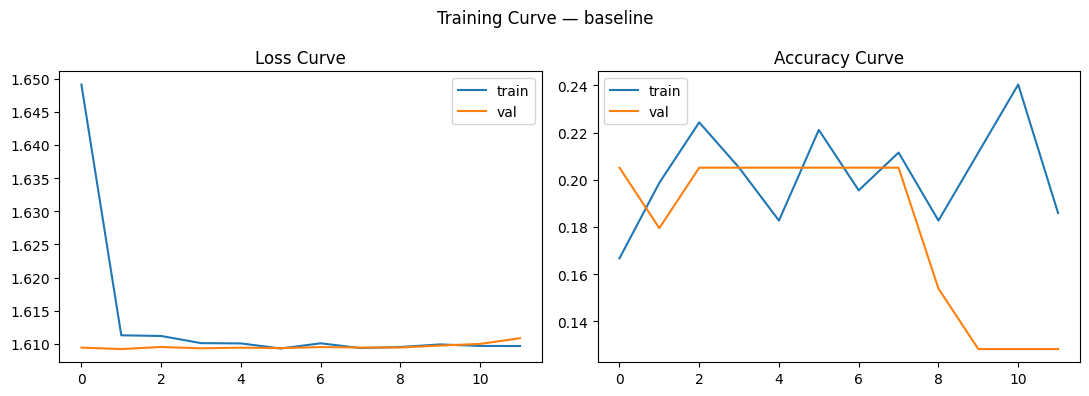


baseline
  Accuracy  : 20.00%
  Loss      : 1.6097
              precision    recall  f1-score   support

          da       0.00      0.00      0.00         8
          ta       0.00      0.00      0.00         8
          sa       0.00      0.00      0.00         8
          wa       0.20      1.00      0.33         8
          la       0.00      0.00      0.00         8

    accuracy                           0.20        40
   macro avg       0.04      0.20      0.07        40
weighted avg       0.04      0.20      0.07        40



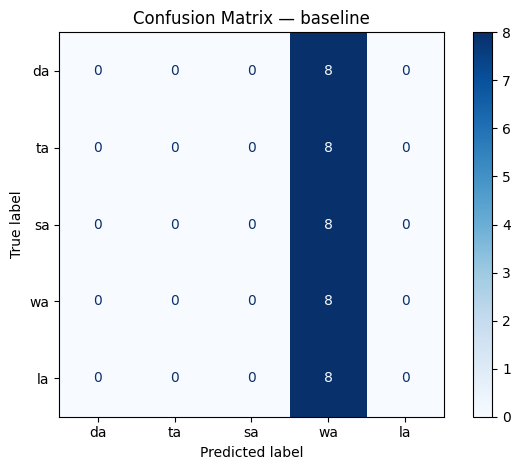


Visualisasi Klasifikasi: baseline


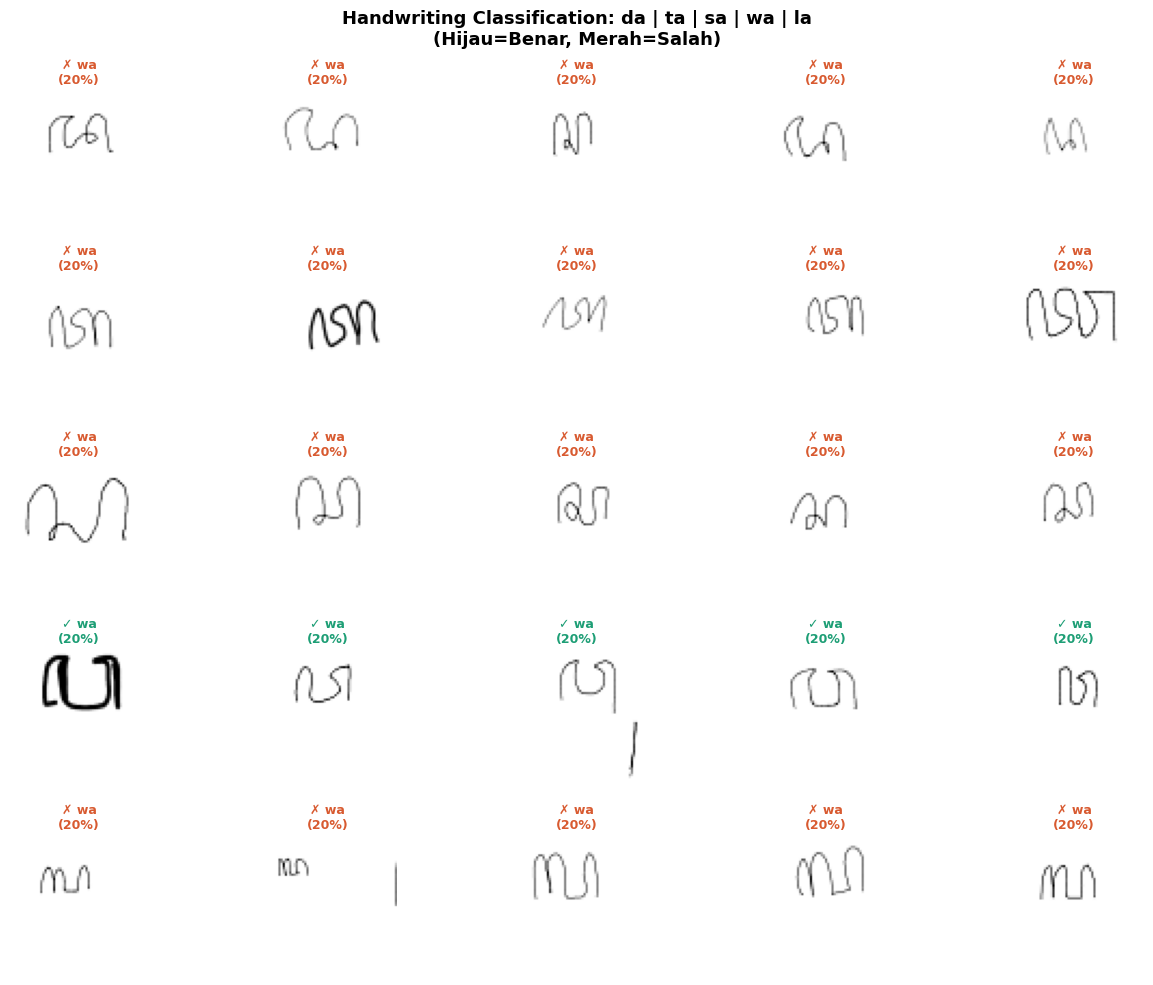

In [ ]:
model_baseline, history_baseline = run_experiment('baseline')

Eksperimen  : exp1_otsu
Konfigurasi : {'noise': None, 'threshold': 'otsu', 'morphology': None, 'skeleton': False}
Train: 312 | Val: 39 | Test: 40
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 323ms/step - accuracy: 0.1827 - loss: 1.6147 - val_accuracy: 0.2821 - val_loss: 1.5968
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 296ms/step - accuracy: 0.2564 - loss: 1.6055 - val_accuracy: 0.3077 - val_loss: 1.5943
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 369ms/step - accuracy: 0.2660 - loss: 1.5938 - val_accuracy: 0.3590 - val_loss: 1.5974
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.2436 - loss: 1.5951 - val_accuracy: 0.4359 - val_loss: 1.5545
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 276ms/step - accuracy: 0.2308 - loss: 1.5931 - val_accuracy: 0.2564 - val_loss: 1.5678
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step - accuracy: 0.2917 - loss: 1.5735 - val_accuracy: 0.5897 - val_loss: 1.5243
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step - accuracy: 0.3558 - loss: 1.5363 

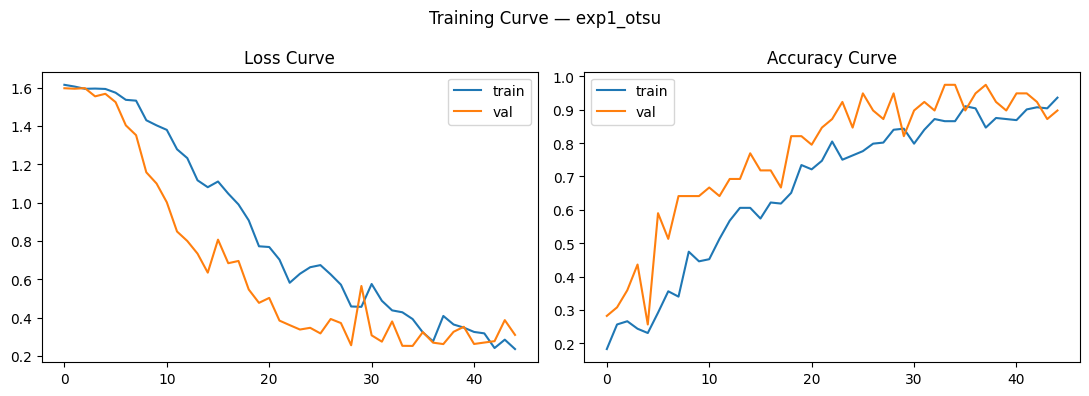


exp1_otsu
  Accuracy  : 92.50%
  Loss      : 0.1676
              precision    recall  f1-score   support

          da       1.00      0.75      0.86         8
          ta       1.00      1.00      1.00         8
          sa       0.73      1.00      0.84         8
          wa       1.00      1.00      1.00         8
          la       1.00      0.88      0.93         8

    accuracy                           0.93        40
   macro avg       0.95      0.93      0.93        40
weighted avg       0.95      0.93      0.93        40



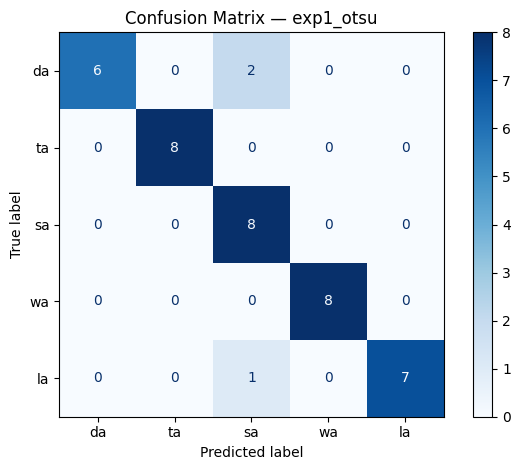


Visualisasi Klasifikasi: exp1_otsu


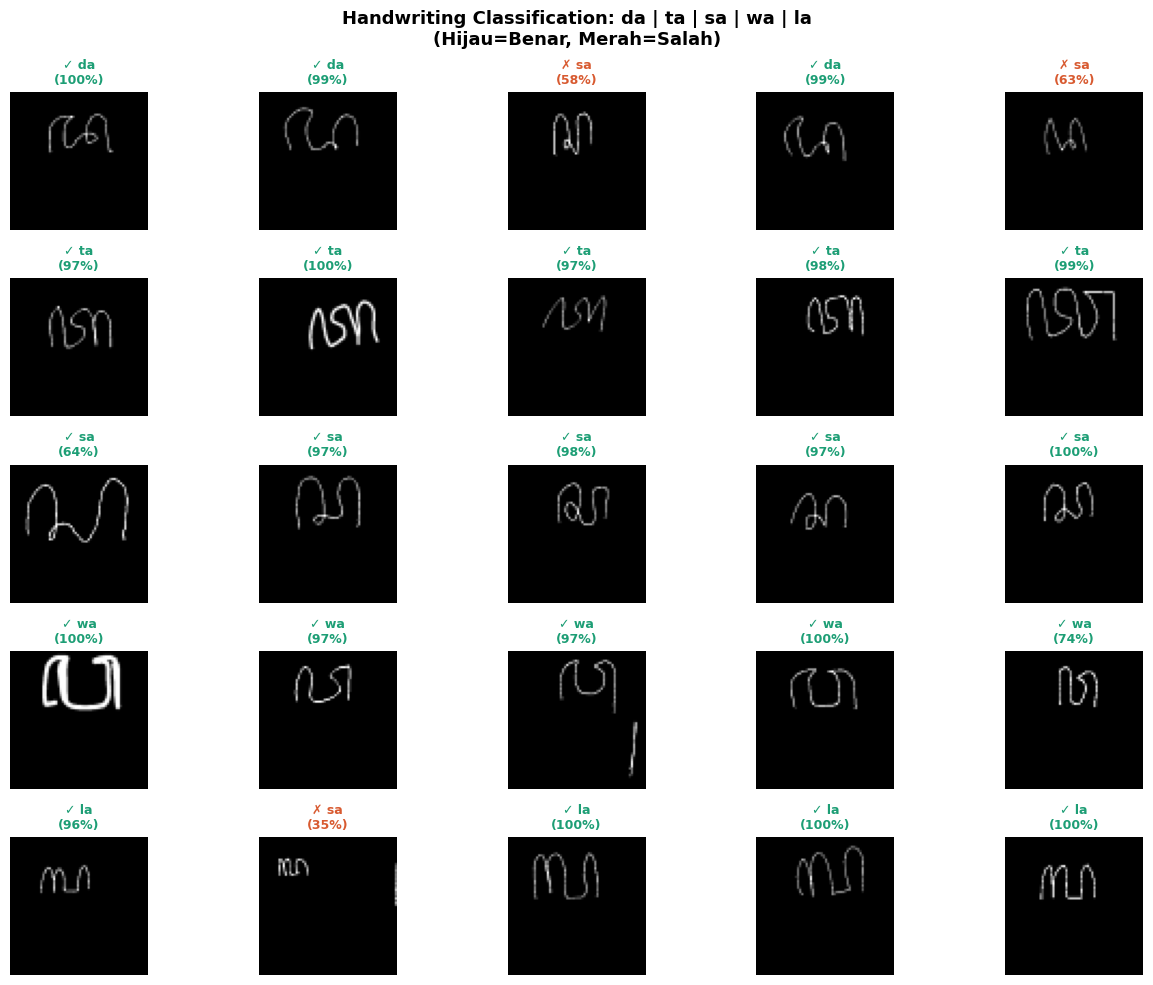

In [ ]:
model_exp1, history_exp1 = run_experiment('exp1_otsu')

Eksperimen  : exp2_median_otsu
Konfigurasi : {'noise': 'median', 'threshold': 'otsu', 'morphology': None, 'skeleton': False}
Train: 312 | Val: 39 | Test: 40
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 404ms/step - accuracy: 0.1923 - loss: 1.6165 - val_accuracy: 0.3077 - val_loss: 1.6106
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - accuracy: 0.1571 - loss: 1.6104 - val_accuracy: 0.1282 - val_loss: 1.6073
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 276ms/step - accuracy: 0.2436 - loss: 1.6090 - val_accuracy: 0.2821 - val_loss: 1.6074
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - accuracy: 0.2083 - loss: 1.6066 - val_accuracy: 0.1795 - val_loss: 1.6063
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 380ms/step - accuracy: 0.2372 - loss: 1.6007 - val_accuracy: 0.1795 - val_loss: 1.5885
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step - accuracy: 0.2660 - loss: 1.5918 - val_accuracy: 0.3590 - val_loss: 1.6034
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 288ms/step - accuracy: 0.2885 - lo

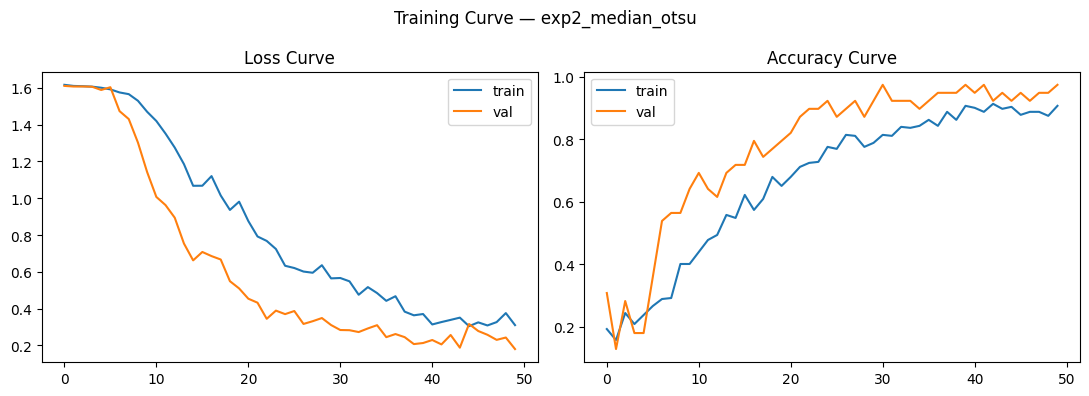


exp2_median_otsu
  Accuracy  : 92.50%
  Loss      : 0.2258
              precision    recall  f1-score   support

          da       1.00      0.75      0.86         8
          ta       0.89      1.00      0.94         8
          sa       0.80      1.00      0.89         8
          wa       1.00      1.00      1.00         8
          la       1.00      0.88      0.93         8

    accuracy                           0.93        40
   macro avg       0.94      0.93      0.92        40
weighted avg       0.94      0.93      0.92        40



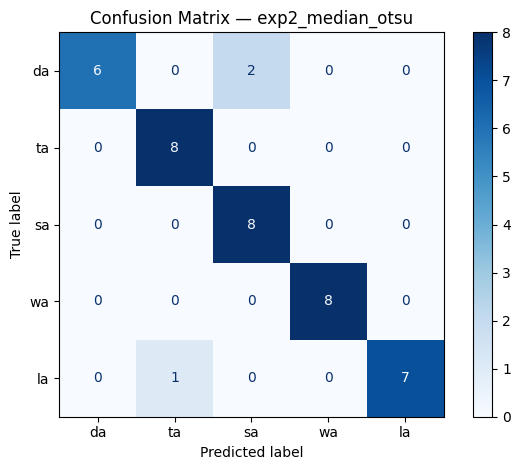


Visualisasi Klasifikasi: exp2_median_otsu


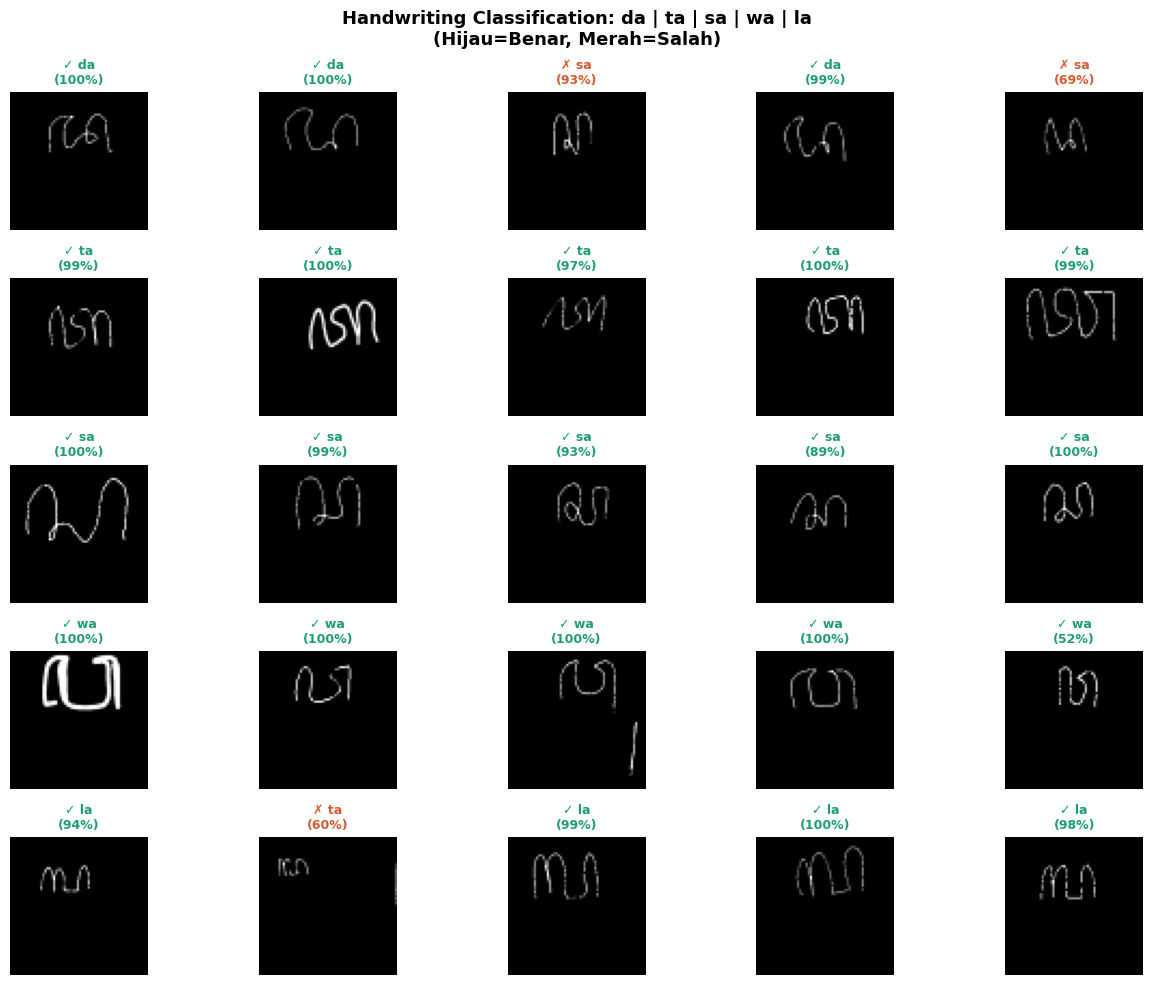

In [ ]:
model_exp2, history_exp2 = run_experiment('exp2_median_otsu')

Eksperimen  : exp3_full
Konfigurasi : {'noise': 'median', 'threshold': 'otsu', 'morphology': 'closing', 'skeleton': False}
Train: 312 | Val: 39 | Test: 40
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - accuracy: 0.2019 - loss: 1.6199 - val_accuracy: 0.4359 - val_loss: 1.6058
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - accuracy: 0.2083 - loss: 1.6066 - val_accuracy: 0.1795 - val_loss: 1.6079
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 327ms/step - accuracy: 0.2083 - loss: 1.6023 - val_accuracy: 0.3333 - val_loss: 1.6003
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 339ms/step - accuracy: 0.2340 - loss: 1.5961 - val_accuracy: 0.2308 - val_loss: 1.5810
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 287ms/step - accuracy: 0.2724 - loss: 1.5807 - val_accuracy: 0.4872 - val_loss: 1.5405
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 0.2788 - loss: 1.5825 - val_accuracy: 0.4872 - val_loss: 1.4759
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.3654 - loss

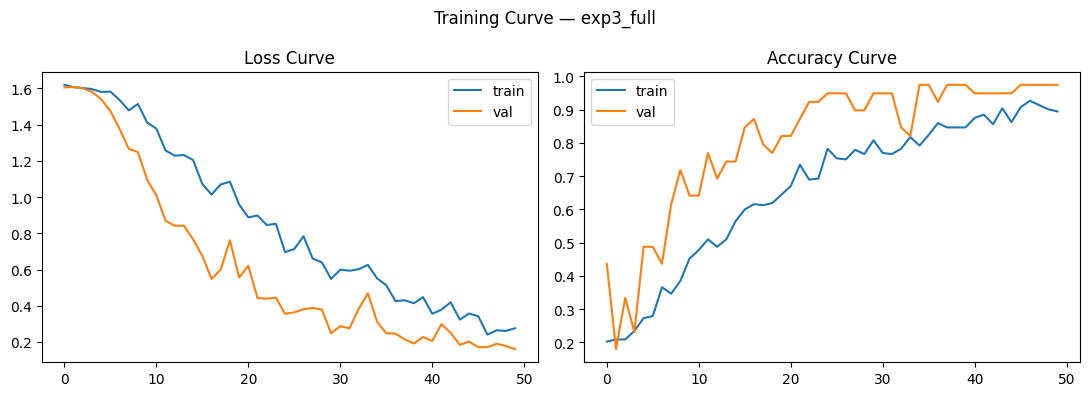


exp3_full
  Accuracy  : 95.00%
  Loss      : 0.2425
              precision    recall  f1-score   support

          da       1.00      0.88      0.93         8
          ta       0.89      1.00      0.94         8
          sa       0.89      1.00      0.94         8
          wa       1.00      0.88      0.93         8
          la       1.00      1.00      1.00         8

    accuracy                           0.95        40
   macro avg       0.96      0.95      0.95        40
weighted avg       0.96      0.95      0.95        40



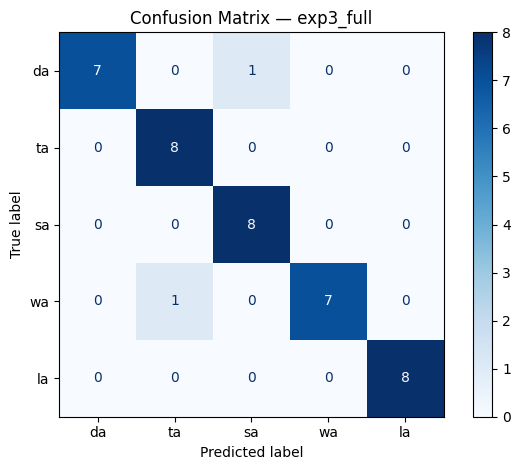


Visualisasi Klasifikasi: exp3_full


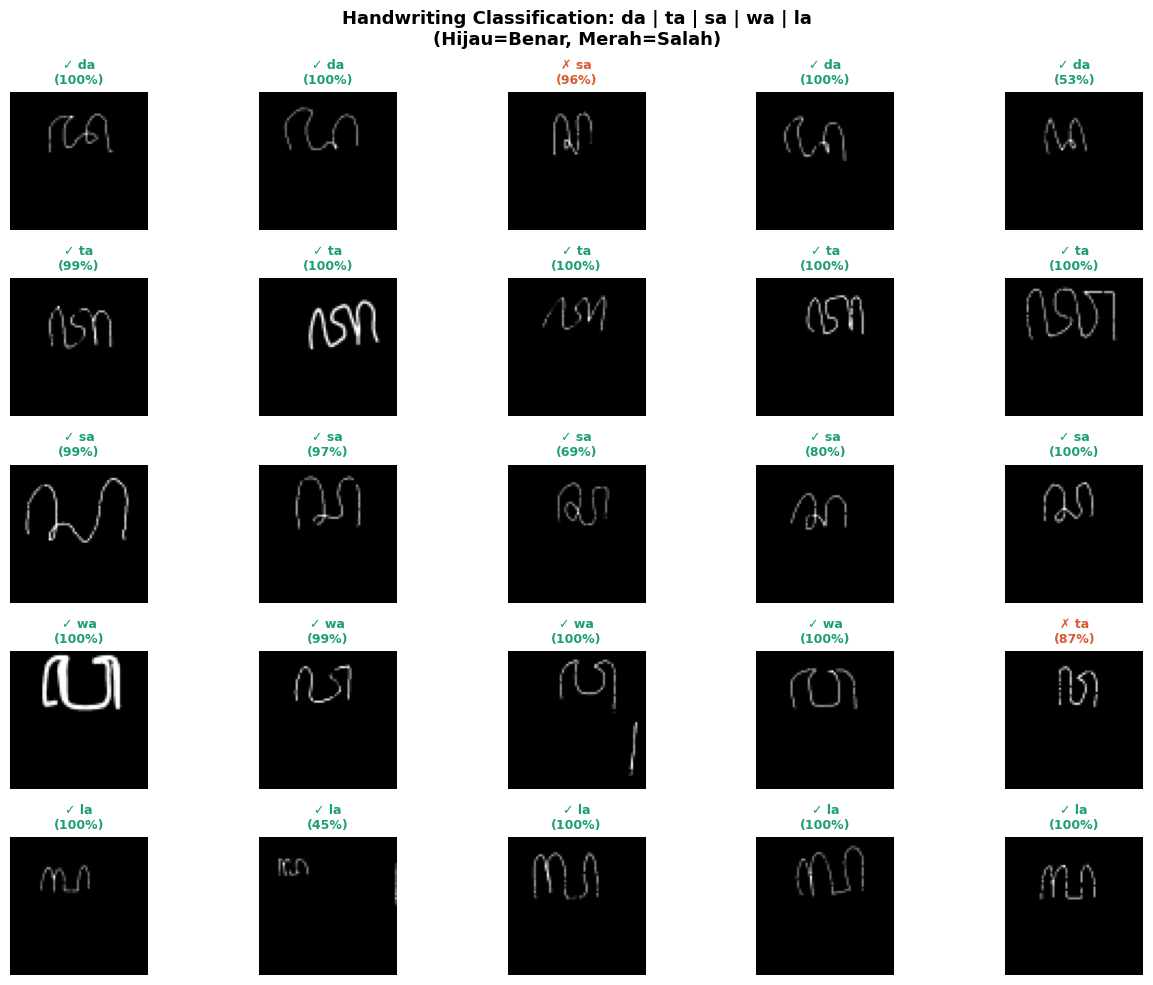

In [ ]:
model_exp3, history_exp3 = run_experiment('exp3_full')

Eksperimen  : exp4_skeleton
Konfigurasi : {'noise': 'median', 'threshold': 'otsu', 'morphology': 'closing', 'skeleton': True}
Train: 312 | Val: 39 | Test: 40
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 314ms/step - accuracy: 0.1731 - loss: 1.6111 - val_accuracy: 0.2308 - val_loss: 1.6049
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 404ms/step - accuracy: 0.2244 - loss: 1.6062 - val_accuracy: 0.3590 - val_loss: 1.5822
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - accuracy: 0.2276 - loss: 1.5995 - val_accuracy: 0.4103 - val_loss: 1.5391
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - accuracy: 0.2532 - loss: 1.5779 - val_accuracy: 0.4615 - val_loss: 1.4815
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.2981 - loss: 1.5426 - val_accuracy: 0.4615 - val_loss: 1.3701
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 349ms/step - accuracy: 0.3558 - loss: 1.5027 - val_accuracy: 0.5128 - val_loss: 1.2779
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step - accuracy: 0.4327 - l

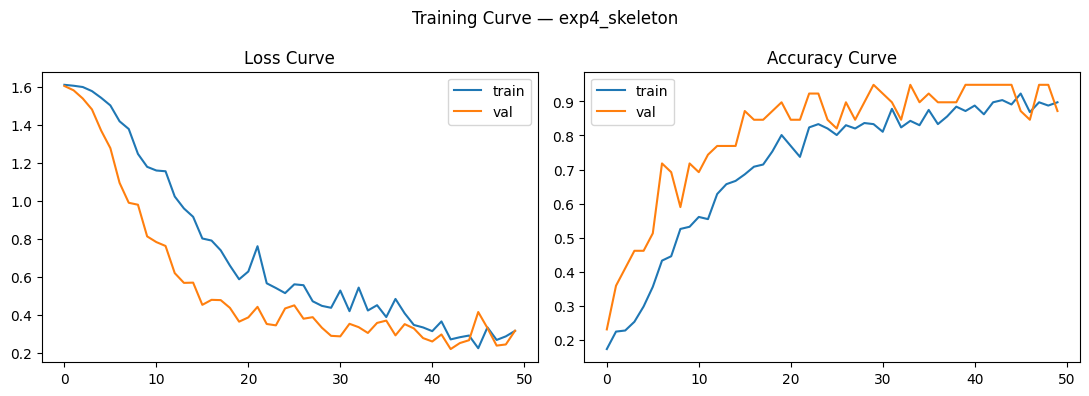


exp4_skeleton
  Accuracy  : 97.50%
  Loss      : 0.0730
              precision    recall  f1-score   support

          da       1.00      0.88      0.93         8
          ta       1.00      1.00      1.00         8
          sa       0.89      1.00      0.94         8
          wa       1.00      1.00      1.00         8
          la       1.00      1.00      1.00         8

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



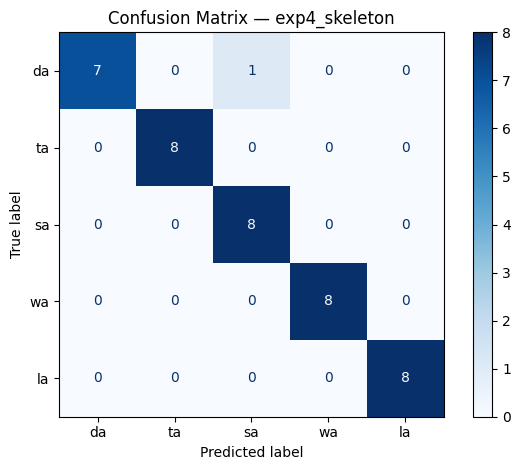


Visualisasi Klasifikasi: exp4_skeleton


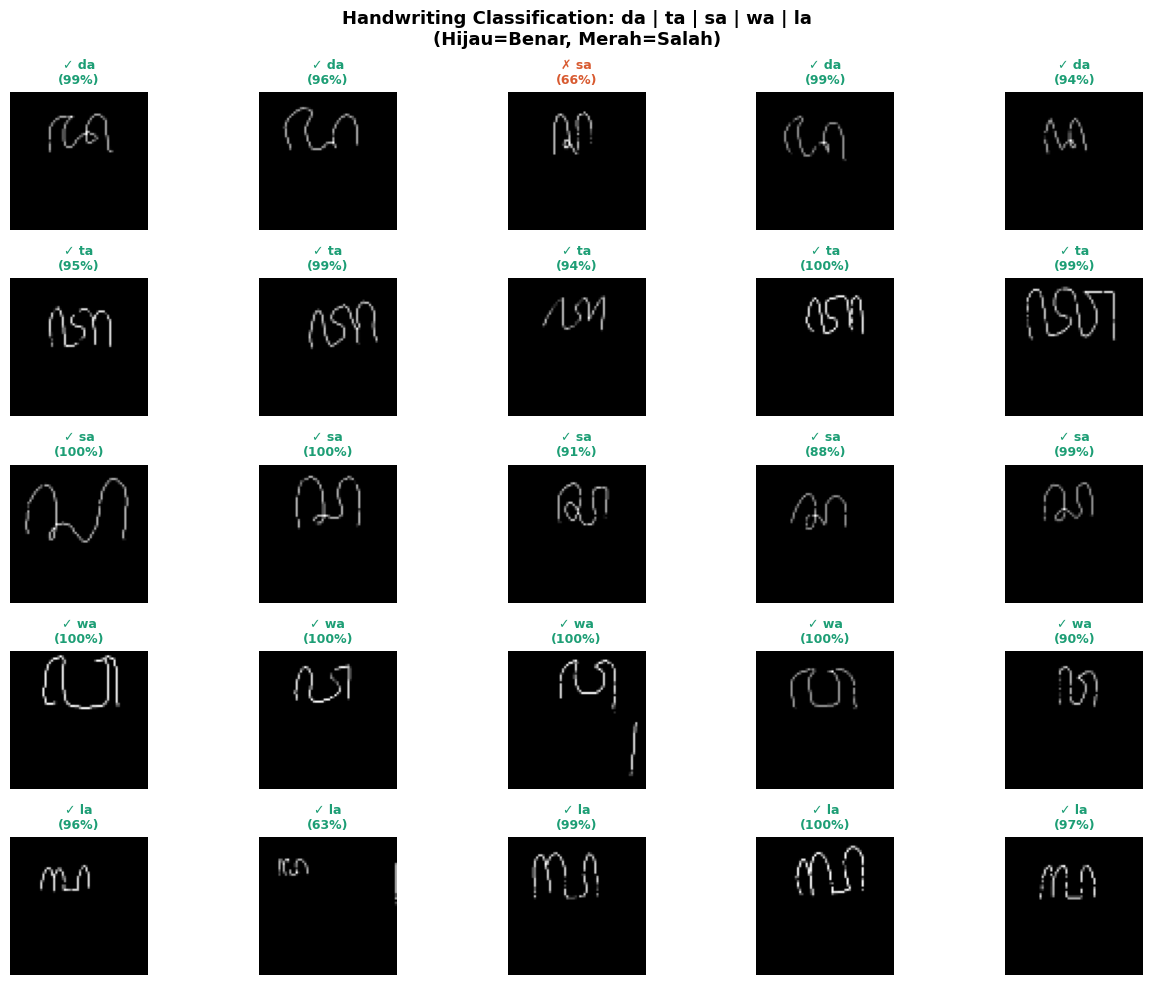

In [ ]:
model_exp4, history_exp4 = run_experiment('exp4_skeleton')


RINGKASAN SEMUA EKSPERIMEN
Eksperimen                  Accuracy     Loss
---------------------------------------------
exp4_skeleton                 97.50%    0.0730
exp3_full                     95.00%    0.2425
exp1_otsu                     92.50%    0.1676
exp2_median_otsu              92.50%    0.2258
baseline                      20.00%    1.6097


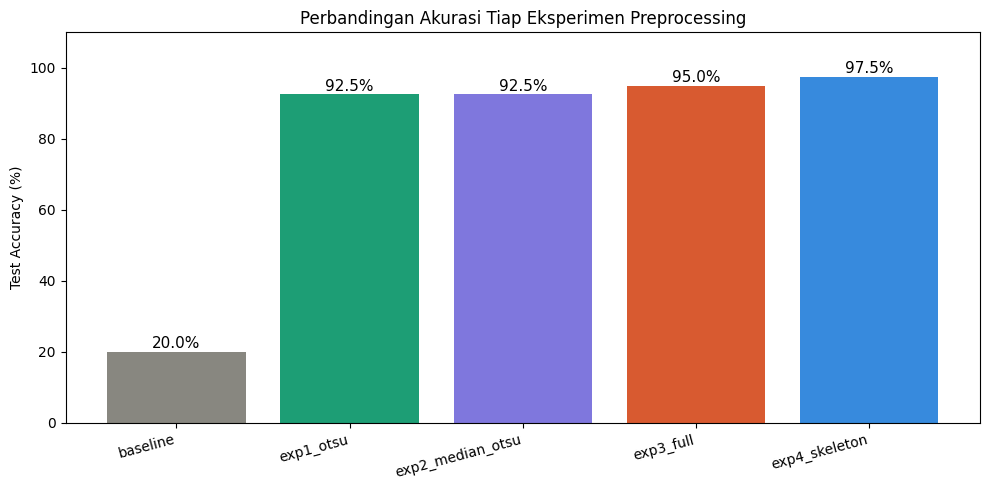

In [ ]:
print("\nRINGKASAN SEMUA EKSPERIMEN")
print(f"{'Eksperimen':<25} {'Accuracy':>10} {'Loss':>8}")
print("-" * 45)
for r in sorted(all_results, key=lambda x: -x['accuracy']):
    print(f"{r['name']:<25} {r['accuracy']*100:>9.2f}%  {r['loss']:>8.4f}")

# Plot Accuracy
names = [r['name'] for r in all_results]
accs  = [r['accuracy'] * 100 for r in all_results]
colors = ['#888780', '#1D9E75', '#7F77DD', '#D85A30', '#378ADD']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, color=colors)
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Perbandingan Akurasi Tiap Eksperimen Preprocessing')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()